In [2]:
import pandas as pd
import os

# Dataset folder path
data_path = r"E:\new Projects\Data-Analytics-Framework-for-Business-Decision-Support\Dataset\Raw Dataset"

# -------------------------------
# Load all datasets
# -------------------------------
datasets = {
    "customers": pd.read_csv(os.path.join(data_path, "olist_customers_dataset.csv")),
    "orders": pd.read_csv(os.path.join(data_path, "olist_orders_dataset.csv")),
    "order_items": pd.read_csv(os.path.join(data_path, "olist_order_items_dataset.csv")),
    "payments": pd.read_csv(os.path.join(data_path, "olist_order_payments_dataset.csv")),
    "reviews": pd.read_csv(os.path.join(data_path, "olist_order_reviews_dataset.csv")),
    "products": pd.read_csv(os.path.join(data_path, "olist_products_dataset.csv")),
    "sellers": pd.read_csv(os.path.join(data_path, "olist_sellers_dataset.csv")),
    "geolocation": pd.read_csv(os.path.join(data_path, "olist_geolocation_dataset.csv")),
    "category_translation": pd.read_csv(os.path.join(data_path, "product_category_name_translation.csv"))
}

# Dataset references
customers = datasets["customers"]
orders = datasets["orders"]
order_items = datasets["order_items"]
payments = datasets["payments"]
reviews = datasets["reviews"]
products = datasets["products"]
sellers = datasets["sellers"]
geolocation = datasets["geolocation"]
category_translation = datasets["category_translation"]

print("✅ Data ingestion completed successfully")

✅ Data ingestion completed successfully


In [4]:
import pandas as pd

# -------------------------------
# Orders: Convert timestamp columns
# -------------------------------
orders_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in orders_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# -------------------------------
# Order Items
# -------------------------------
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"], errors="coerce"
)

# -------------------------------
# Reviews
# -------------------------------
reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"], errors="coerce"
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"], errors="coerce"
)

# -------------------------------
# Payments
# -------------------------------
payments["payment_installments"] = pd.to_numeric(
    payments["payment_installments"], errors="coerce"
)

payments["payment_value"] = pd.to_numeric(
    payments["payment_value"], errors="coerce"
)

# -------------------------------
# Products numeric conversion
# -------------------------------
product_numeric_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in product_numeric_cols:
    products[col] = pd.to_numeric(products[col], errors="coerce")

# -------------------------------
# Memory optimization (categorical encoding)
# -------------------------------
orders["order_status"] = orders["order_status"].astype("category")
payments["payment_type"] = payments["payment_type"].astype("category")
products["product_category_name"] = products["product_category_name"].astype("category")
customers["customer_state"] = customers["customer_state"].astype("category")
sellers["seller_state"] = sellers["seller_state"].astype("category")

print("✅ Data type standardization completed")

✅ Data type standardization completed


In [5]:
import numpy as np

# -------------------------------
# ORDERS (create business flags instead of imputation)
# -------------------------------
orders["is_delivered"] = orders["order_delivered_customer_date"].notna()
orders["is_shipped"] = orders["order_delivered_carrier_date"].notna()
orders["is_approved"] = orders["order_approved_at"].notna()

orders["is_pending"] = ~orders["is_delivered"]

orders["order_status_clean"] = np.where(
    orders["is_delivered"], "delivered",
    np.where(orders["is_shipped"], "shipped", "processing")
)

# -------------------------------
# REVIEWS (text imputation)
# -------------------------------
reviews["review_comment_title"] = reviews["review_comment_title"].fillna("No Title")
reviews["review_comment_message"] = reviews["review_comment_message"].fillna("No Comment")

# -------------------------------
# PRODUCTS (categorical + median imputation)
# -------------------------------
products["product_category_name"] = products["product_category_name"].cat.add_categories("unknown")
products["product_category_name"] = products["product_category_name"].fillna("unknown")

product_medians = {
    "product_name_lenght": products["product_name_lenght"].median(),
    "product_description_lenght": products["product_description_lenght"].median(),
    "product_photos_qty": products["product_photos_qty"].median(),
    "product_weight_g": products["product_weight_g"].median()
}

products = products.fillna(product_medians)

print("✅ Missing value handling completed")

✅ Missing value handling completed


In [6]:
# -------------------------------
# Delivery delay (SLA analysis)
# -------------------------------
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_estimated_delivery_date"]
).dt.days

# -------------------------------
# Actual delivery time
# -------------------------------
orders["actual_delivery_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

# -------------------------------
# Monthly aggregation
# -------------------------------
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

# -------------------------------
# SLA breach
# -------------------------------
orders["sla_breached"] = orders["delivery_delay_days"] > 0

# -------------------------------
# Revenue feature
# -------------------------------
order_items["net_revenue"] = order_items["price"] - order_items["freight_value"]

print("✅ Feature engineering completed")

✅ Feature engineering completed


In [7]:
snapshot_date = orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    orders.merge(customers, on="customer_id")
    .merge(payments, on="order_id")
    .groupby("customer_unique_id")
    .agg(
        Recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
        Frequency=("order_id", "nunique"),
        Monetary=("payment_value", "sum")
    )
    .reset_index()
)

# RFM scoring
rfm["R"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1])
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm["M"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4])

print("✅ RFM segmentation completed")

✅ RFM segmentation completed


In [8]:
first_purchase = (
    orders[orders["order_status"] == "delivered"]
    .merge(customers, on="customer_id")
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .dt.to_period("M")
    .rename("CohortMonth")
)

print("✅ Cohort assignment completed")

✅ Cohort assignment completed


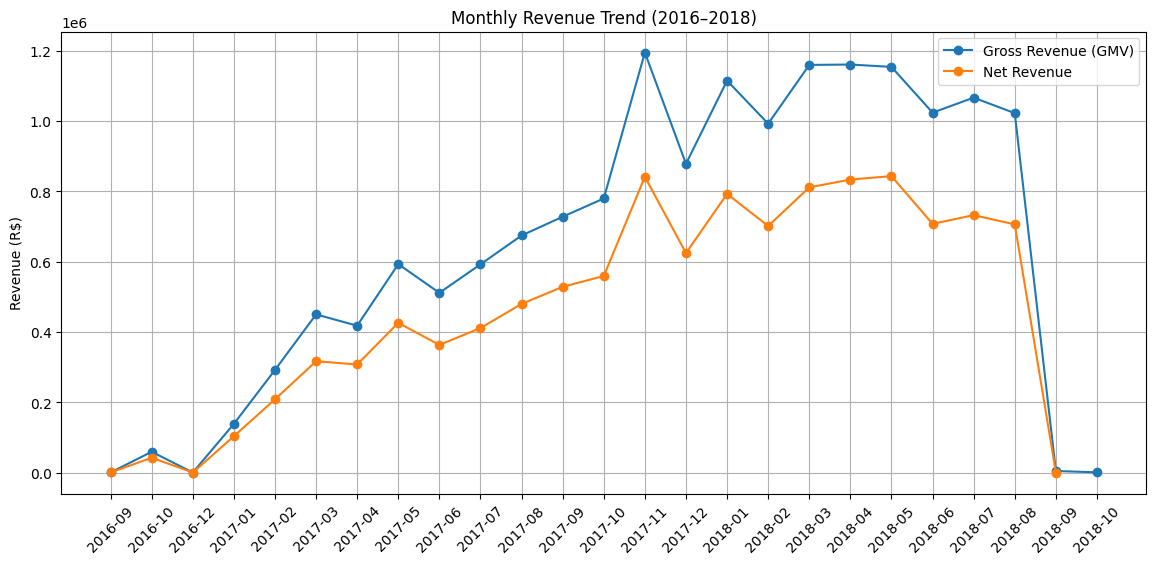

Total Gross Revenue: 16008872.12
Total Net Revenue: 11339734.16
Margin Erosion: 4669137.959999999


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Merge orders + payments for gross revenue
# -------------------------------
orders_payments = orders.merge(payments, on="order_id")

orders_payments["order_month"] = orders_payments["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Gross revenue (GMV)
monthly_gross = orders_payments.groupby("order_month")["payment_value"].sum()

# Net revenue (from order_items)
orders_items = orders.merge(order_items, on="order_id")

orders_items["net_revenue"] = orders_items["price"] - orders_items["freight_value"]
orders_items["order_month"] = orders_items["order_purchase_timestamp"].dt.to_period("M").astype(str)

monthly_net = orders_items.groupby("order_month")["net_revenue"].sum()

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(14,6))
plt.plot(monthly_gross.index, monthly_gross.values, label="Gross Revenue (GMV)", marker="o")
plt.plot(monthly_net.index, monthly_net.values, label="Net Revenue", marker="o")

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend (2016–2018)")
plt.ylabel("Revenue (R$)")
plt.legend()
plt.grid()

plt.show()

# Summary values
print("Total Gross Revenue:", monthly_gross.sum())
print("Total Net Revenue:", monthly_net.sum())
print("Margin Erosion:", monthly_gross.sum() - monthly_net.sum())

C:\Users\User\AppData\Local\Temp\ipykernel_5160\1580414575.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="viridis")


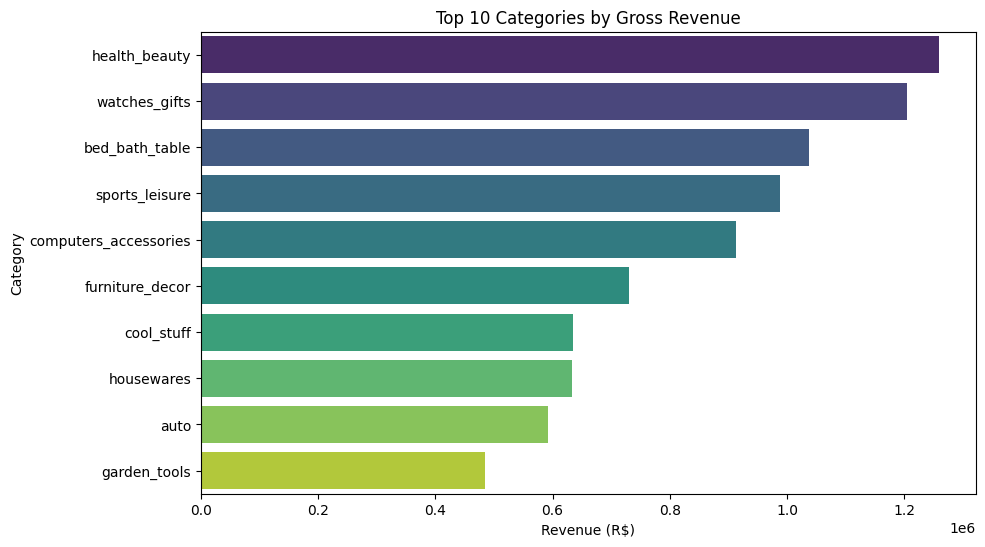

In [10]:
# -------------------------------
# Merge for category revenue
# -------------------------------
cat_df = order_items.merge(products, on="product_id") \
                    .merge(category_translation, on="product_category_name", how="left")

# Replace missing translations
cat_df["product_category_name_english"] = cat_df["product_category_name_english"].fillna("unknown")

# Revenue by category
category_revenue = cat_df.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False)

# Top 10 categories
top10 = category_revenue.head(10)

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index, palette="viridis")

plt.title("Top 10 Categories by Gross Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("Category")

plt.show()

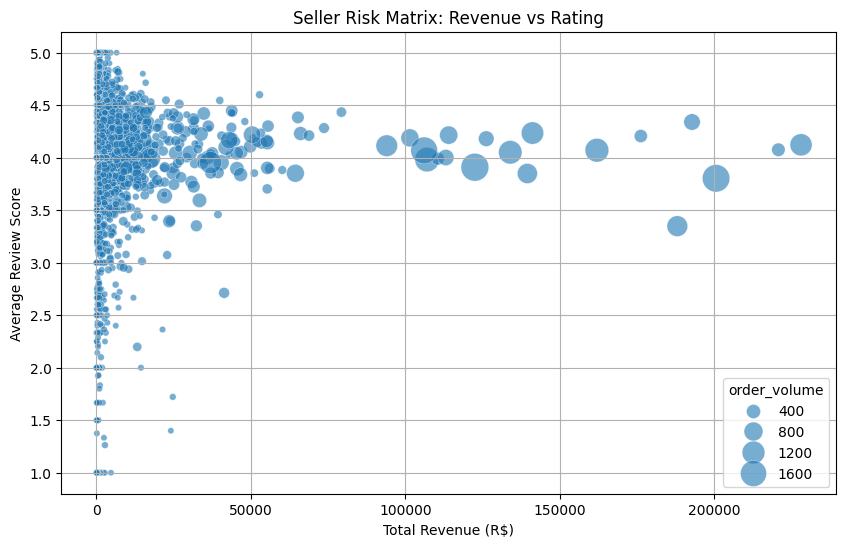

                             seller_id  total_revenue  avg_rating  \
854   4869f7a5dfa277a7dca6462dcf3b52b2      228071.04    4.122822   
1010  53243585a1d6dc2643021fd1853d8905      220740.05    4.075980   
878   4a3ca9315b744ce9f8e9374361493884      200561.42    3.803931   
3019  fa1c13f2614d7b5c4749cbc52fecda94      192774.43    4.340206   
1532  7c67e1448b00f6e969d365cea6b010ab      188017.85    3.348208   
1557  7e93a43ef30c4f03f38b393420bc753a      176201.88    4.206490   
2638  da8622b14eb17ae2831f4ac5b9dab84a      161993.97    4.071429   
1502  7a67c85e85bb2ce8582c35f2203ad736      141130.58    4.234991   
192   1025f0e2d44d7041d6cf58b6550e0bfa      139484.38    3.849755   
1820  955fee9216a65b617aa5c0531780ce60      133948.81    4.051713   

      order_volume  
854           1124  
1010           356  
878           1785  
3019           581  
1532           976  
1557           335  
2638          1308  
1502          1151  
192            907  
1820          1277  


In [11]:
# -------------------------------
# Merge seller + orders + reviews + order_items
# -------------------------------
seller_df = order_items.merge(orders, on="order_id") \
                       .merge(reviews, on="order_id")

# Revenue per seller
seller_metrics = seller_df.groupby("seller_id").agg(
    total_revenue=("price", "sum"),
    avg_rating=("review_score", "mean"),
    order_volume=("order_id", "nunique")
).reset_index()

# -------------------------------
# Seller Risk Matrix
# -------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=seller_metrics,
    x="total_revenue",
    y="avg_rating",
    size="order_volume",
    sizes=(20, 400),
    alpha=0.6
)

plt.title("Seller Risk Matrix: Revenue vs Rating")
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Average Review Score")
plt.grid()
plt.show()

# -------------------------------
# Top sellers ranking
# -------------------------------
top_sellers = seller_metrics.sort_values("total_revenue", ascending=False).head(10)
print(top_sellers)

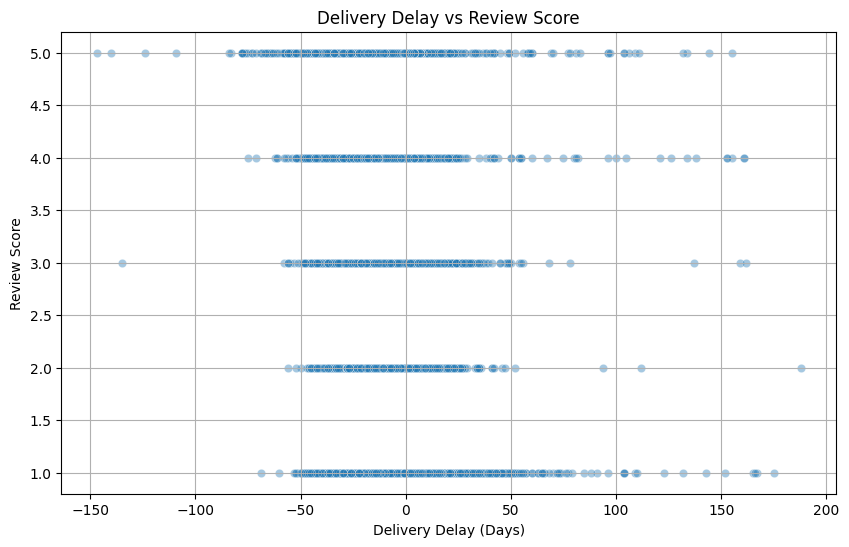

Average Delivery Time: 12.094085575687217
SLA Compliance Rate (%): 90.44659647429128


In [12]:
# -------------------------------
# Delivery delay calculation
# -------------------------------
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_estimated_delivery_date"]
).dt.days

orders["actual_delivery_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

# Merge with reviews for rating impact
logistics_df = orders.merge(reviews, on="order_id")

# -------------------------------
# Scatter: Delay vs Review Score
# -------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=logistics_df,
    x="delivery_delay_days",
    y="review_score",
    alpha=0.4
)

plt.title("Delivery Delay vs Review Score")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Review Score")
plt.grid()
plt.show()

# -------------------------------
# SLA compliance
# -------------------------------
sla_rate = (orders["delivery_delay_days"] <= 0).mean() * 100
avg_delivery = orders["actual_delivery_days"].mean()

print("Average Delivery Time:", avg_delivery)
print("SLA Compliance Rate (%):", sla_rate)

In [19]:
for col in df.columns:
    if str(df[col].dtype) == "period[M]" or "Period" in str(df[col].dtype):
        df[col] = df[col].astype(str)

In [17]:
pip install pandas sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [20]:
from sqlalchemy import create_engine

# -------------------------------
# PostgreSQL Connection
# -------------------------------
username = "postgres"
password = "tushar"
host = "localhost"
port = "5432"
database = "olist_db"

engine = create_engine(f"postgresql://{username}:{password}@{host}:{port}/{database}")

print("✅ PostgreSQL connection established")

# -------------------------------
# Load all datasets into PostgreSQL
# -------------------------------
for name, df in datasets.items():
    df.to_sql(
        name=name,
        con=engine,
        if_exists="replace",
        index=False,
        chunksize=1000
    )
    print(f"✅ {name} loaded into database")

✅ PostgreSQL connection established
✅ customers loaded into database
✅ orders loaded into database
✅ order_items loaded into database
✅ payments loaded into database
✅ reviews loaded into database
✅ products loaded into database
✅ sellers loaded into database
✅ geolocation loaded into database
✅ category_translation loaded into database
